In [1]:
using Distributions, Random, Statistics, MultipleTesting, Empirikos, Hypatia, LinearAlgebra
using Distributions, StatsPlots, Random
Random.seed!(105)
n_values = [3, 4, 5, 6, 8, 10]
G = 1000
R = 100
p_signal = 0.1
β_signal = 2

# limma-style variance prior hyperparameters
d0 = 2.0
s0² = 1.0

# scaled-inv-chi-square(df=d0, scale=s0²)
# equivalent inverse-gamma params:
# σ² ~ InverseGamma(d0/2, d0*s0²/2)
a = d0 / 2
b = d0 * s0² / 2

datasets = Dict{Tuple{Int,Int}, Any}()

for n in n_values
    for r in 1:R
        rng = MersenneTwister(100_000 + 100n + r)

        is_DE = rand(rng, G) .< p_signal
        σ2 = rand(rng, InverseGamma(a, b), G)
        σ  = sqrt.(σ2)

        Y = [
            rand(rng, Normal(is_DE[i] ? β_signal * σ[i] : 0.0, σ[i]), n)
            for i in 1:G
        ]

        datasets[(n,r)] = (Y=Y, is_DE=is_DE, σ=σ, σ2=σ2)
    end
end

## Mean + SD

In [2]:
R=100
# --- Storage for summary results ---
epb_summary = Dict(
    "n" => Int[],
    "TP" => Float64[],
    "FP" => Float64[],
    "Power" => Float64[],
    "FDR" => Float64[]
)

# --- Loop over sample sizes ---
for n in n_values
    println("\n========== Running EPB NPMLE simulation for n = $n ==========")
    ν = n - 1

    power_vals = Float64[]
    fdr_vals   = Float64[]
    tp_vals    = Float64[]
    fp_vals    = Float64[]

    for r in 1:R
        try
            # 1️⃣ Simulate true effects and per-gene noise
            (Y, is_DE, σ) = (datasets[(n,r)].Y, datasets[(n,r)].is_DE, datasets[(n,r)].σ)
            # is_DE   = rand(G) .< p_signal
            # σ_true  = σ_support[rand(Categorical(π_true), G)]

            # # 2️⃣ Simulate data per gene
            # Y = [rand(Normal(is_DE[i] ? β_signal * σ_true[i] : 0.0, σ_true[i]), n) for i in 1:G]

            # 3️⃣ Compute statistics
            β_hat = [mean(Y[i]) for i in 1:G]
            s_hat = [std(Y[i], corrected=true) for i in 1:G]
            se_hat_squared = (s_hat .^ 2) ./ n

            # 4️⃣ Build Normal–Chi-square samples
            samples = [Empirikos.NormalChiSquareSample(β_hat[i], se_hat_squared[i], ν) for i in 1:G]

            # 5️⃣ Fit EPB with nonparametric NPMLE prior
            test_epb = Empirikos.EmpiricalPartiallyBayesTTest(α = 0.05, solver = Hypatia.Optimizer)
            res_epb  = fit(test_epb, samples)

            # 6️⃣ Extract results
            pvals_epb = res_epb.pvalue
            rej_epb   = res_epb.rj_idx

            TP  = sum(rej_epb .&  is_DE)
            FP  = sum(rej_epb .& .!is_DE)
            power = TP / max(sum(is_DE), 1)
            fdr   = FP / max(sum(rej_epb), 1)

            push!(tp_vals, TP)
            push!(fp_vals, FP)
            push!(power_vals, power)
            push!(fdr_vals, fdr)

            println("Rep $r → Power=$(round(power, digits=3)) | FDR=$(round(fdr, digits=3)) | Rej=$(sum(rej_epb))")

        catch e
            println("⚠️  Skipping Rep $r for n=$n due to error: $(typeof(e))")
            continue
        end
    end

    # --- Summarize results for this n ---
    mean_TP = mean(tp_vals)
    mean_FP = mean(fp_vals)
    mean_power = mean(power_vals)
    mean_fdr = mean(fdr_vals)

    push!(epb_summary["n"], n)
    push!(epb_summary["TP"], mean_TP)
    push!(epb_summary["FP"], mean_FP)
    push!(epb_summary["Power"], mean_power)
    push!(epb_summary["FDR"], mean_fdr)

    println("n = $n → Power=$(round(mean_power, digits=3)) | FDR=$(round(mean_fdr, digits=3)) | TP=$(round(mean_TP, digits=1)) | FP=$(round(mean_FP, digits=1))")
end


========== Running EPB NPMLE simulation for n = 3 ==========

 iter        p_obj        d_obj |  abs_gap    x_feas    z_feas |      tau       kap        mu | dir_res     prox  step     alpha
    0   3.2373e-02  -2.5627e+02 | 2.30e+03  1.52e+02  3.14e+00 | 1.00e+00  1.00e+00  1.00e+00 |
    1  -9.5251e-01  -2.6085e+02 | 2.19e+03  1.54e+02  3.19e+00 | 9.37e-01  1.02e+00  9.50e-01 | 2.6e-12  8.8e-02  co-a  5.00e-02
    2  -2.3225e+00  -2.6368e+02 | 2.08e+03  1.55e+02  3.21e+00 | 8.85e-01  1.02e+00  9.03e-01 | 8.2e-13  1.4e-01  co-a  5.00e-02
    3  -6.2525e+00  -2.6831e+02 | 1.87e+03  1.56e+02  3.22e+00 | 7.94e-01  1.02e+00  8.12e-01 | 8.0e-13  4.0e-01  co-a  1.00e-01
    4  -1.2289e+01  -2.7519e+02 | 1.68e+03  1.56e+02  3.23e+00 | 7.12e-01  1.03e+00  7.31e-01 | 2.1e-12  9.0e-02  co-a  1.00e-01
    5  -2.0653e+01  -2.8364e+02 | 1.51e+03  1.56e+02  3.23e+00 | 6.40e-01  1.03e+00  6.58e-01 | 9.0e-12  3.3e-02  co-a  1.00e-01
    6  -3.2066e+01  -2.9496e+02 | 1.36e+03  1.56e+02  3.23e+00 | 5.

Excessive output truncated after 524295 bytes.

In [3]:
# --- Final summary table ---
println("\n========== SD EPB (NPMLE) SUMMARY ACROSS SAMPLE SIZES ==========")
for i in 1:length(epb_summary["n"])
    println("n = $(epb_summary["n"][i]) → TP=$(round(epb_summary["TP"][i], digits=3)), FP=$(round(epb_summary["FP"][i], digits=3)), Power=$(round(epb_summary["Power"][i], digits=5)), FDR=$(round(epb_summary["FDR"][i], digits=5))")
end


========== SD EPB (NPMLE) SUMMARY ACROSS SAMPLE SIZES ==========
n = 3 → TP=1.4, FP=0.22, Power=0.01392, FDR=0.08158
n = 4 → TP=9.57, FP=0.71, Power=0.09449, FDR=0.06057
n = 5 → TP=42.4, FP=2.08, Power=0.41895, FDR=0.04395
n = 6 → TP=70.414, FP=3.818, Power=0.70481, FDR=0.04974
n = 8 → TP=93.265, FP=4.918, Power=0.93648, FDR=0.04923
n = 10 → TP=98.657, FP=4.646, Power=0.99129, FDR=0.04463


In [20]:
using DataFrames, CSV

df = DataFrame(
    n = epb_summary["n"],
    TP = epb_summary["TP"],
    FP = epb_summary["FP"],
    Power = epb_summary["Power"],
    FDR = epb_summary["FDR"],
)

CSV.write("epb_summary13.csv", df)
println("Wrote epb_summary13.csv")

Wrote epb_summary13.csv


## Mean + Mad

In [4]:

using Distributions, ApproxFun, SpecialFunctions, QuadGK

# ---- distribution type ----
struct MADDistribution{T<:Real,S<:Integer} <: ContinuousUnivariateDistribution
    σ::T
    n::S
end

# ---- import functions we will EXTEND from Distributions ----
import Distributions: pdf, logpdf, insupport, minimum, maximum

# ---- your helpers (unchanged) ----
function G_recursive(max_r::Int; a=0.0, b=100)
    d = Interval(a, b)
    G = Vector{Fun}(undef, max_r+1)
    G[1] = Fun(x -> 1.0, d)
    for r in 1:max_r
        integrand = Fun(x -> exp(-(x^2)/(2r*(r+1))), d) * G[r]
        G[r+1] = cumsum(integrand)
    end
    return G
end

const _Gcache = Dict{Int,Vector{Fun}}()
_getG(n) = get!(_Gcache, n) do; G_recursive(n) end

function _pdf_sigma1(n::Int, m::Real)
    m < 0 && return zero(float(m))          # support m ≥ 0
    z   = n*m/2
    cst = n^(3/2) / (2^((n+1)/2) * π^((n-1)/2))
    G   = _getG(n)
    s   = 0.0
    @inbounds for k in 1:(n-1)
        s += binomial(n,k) * exp(-(m^2 * n^3)/(8k*(n-k))) * G[k](z) * G[n-k](z)
    end
    return cst*s
end

# ---- extend Distributions API ----
# support (MAD ≥ 0)
insupport(::MADDistribution, x::Real) = x ≥ 0
minimum(::MADDistribution) = 0.0
maximum(::MADDistribution) = Inf

# pdf / logpdf (general σ via scaling)
pdf(d::MADDistribution, m::Real) =
    m < 0 ? 0.0 : (1 / d.σ) * _pdf_sigma1(d.n, m / d.σ)

# logpdf(d::MADDistribution, m::Real) =
#     m < 0 ? -Inf : log(pdf(d, m))

# optional convenience
Base.:*(d::MADDistribution, s::Real) = MADDistribution(d.σ * s, d.n)
Base.:*(s::Real, d::MADDistribution) = d * s

using StatsFuns: logsumexp  # you may need to `Pkg.add("StatsFuns")`

function logpdf(d::MADDistribution, m::Real)
    m < 0 && return -Inf
    σ, n = d.σ, d.n

    # Constants
    z   = n * m / (2σ)
    logC = (3/2)*log(n) - ((n+1)/2)*log(2) - ((n-1)/2)*log(π)
    G = _getG(n)

    # Compute all log-terms (inside the sum)
    logs = Float64[]
    for k in 1:(n-1)
        val1 = G[k](z)
        val2 = G[n-k](z)
        if val1 > 0 && val2 > 0
            logterm = log(binomial(n,k)) -
                      (m^2 * n^3)/(8σ^2 * k*(n-k)) +
                      log(val1) + log(val2)
            push!(logs, logterm)
        end
    end

    # Combine safely
    logsum = isempty(logs) ? -Inf : logsumexp(logs)
    return -log(σ) + logC + logsum
end

using Empirikos, Distributions

# 1) evidence type — must subtype EBayesSample
struct MADSample{T,S} <: Empirikos.EBayesSample{T}
    Z::T   # observed MAD
    n::S   # sample size
end

# 2) likelihood at a given σ (must return a Distributions.jl object)
Empirikos.likelihood_distribution(Z::MADSample, σ) = MADDistribution(σ, Z.n)
# Ensure MADDistribution(σ, n) implements pdf/logpdf

# 3) components() for convex prior machinery (vector of likelihoods over σ-support)
Empirikos.components(convexclass::Empirikos.DiscretePriorClass, Z::MADSample) =
    Empirikos.likelihood_distribution.(Ref(Z), Empirikos.support(convexclass))



# limma-style p-value averaged over the posterior on σ
function Empirikos.limma_pvalue(β̂, Z::MADSample, prior::Empirikos.DiscreteNonParametric)
    post = Empirikos.posterior(Z, prior)
    # println("finish post: ")
    # print(post)

    # println(post)
    σs   = Empirikos.support(post)
    # println("finish σs")
    πs   = Empirikos.probs(post)
    # println("finish πs")
    tails = 2 .* ccdf.(Normal.(0, σs), abs(β̂))
    # println("finish tails")
    dot(tails, πs)
    # println("finish dot")
end

In [5]:

# --- Storage for summary results ---
mad_summary = Dict(
    "n" => Int[],
    "TP" => Float64[],
    "FP" => Float64[],
    "Power" => Float64[],
    "FDR" => Float64[]
)

# --- Loop over sample sizes ---
for n in n_values
    println("\n========== Running MAD (t dis) simulation for n = $n ==========")

    tp_vals = Float64[]
    fp_vals = Float64[]
    power_vals = Float64[]
    fdr_vals = Float64[]

    for r in 1:R
        try
            (Y, is_DE, σ) = (datasets[(n,r)].Y, datasets[(n,r)].is_DE, datasets[(n,r)].σ)
            # rng = MersenneTwister(10_000 + 100n + r)

            # # 1️⃣ Generate truth and per-gene σ
            # β_true = rand(rng, G) .< p_signal
     
            # σ = σ_support[rand(rng, Categorical(π_true), G)]
            # # 2️⃣ Simulate data with Cauchy heavy tails
            

            # Y = [rand(rng, Normal(β_true[i] ? β_signal * σ[i] : 0.0, σ[i]), n) for i in 1:G]
            #             # contamination
            # is_cont = contaminate_single_gross_outlier!(Y, σ; p_outlier_gene=0.10, kappa=8.0, rng=rng)
            # # df_t = 3  # degrees of freedom (smaller ⇒ heavier tails)
            # # Y = [rand(TDist(df_t), n) .* σ[i] .+ (β_true[i] ? β_signal * σ[i] : 0.0) for i in 1:G]
            
            # 3️⃣ Compute statistics
            β_hat   = [mean(Y[i]) for i in 1:G]
            mad_obs = [mean(abs.(Y[i] .- β_hat[i])) for i in 1:G]
            β_tilde = sqrt(n) .* β_hat
            

            # 4️⃣ Fit NPMLE prior from MAD samples
            Zs_mad = [MADSample(mad_obs[i], n) for i in 1:G]
            # --- New grid based on MAD data points ---
            σ_grid_raw = sort(unique(mad_obs))
            
            # Thin to at most 200 points (optional but recommended)
            n_grid = 200
            σ_grid = quantile(σ_grid_raw, range(0,1; length=n_grid))
            
            prior_class = Empirikos.DiscretePriorClass(σ_grid)
                        

            # npmle = Empirikos.NPMLE(prior_class, Hypatia.Optimizer) 
            npmle = Empirikos.NPMLE(prior_class, Hypatia.Optimizer)

            fitres = Empirikos.fit(npmle, Zs_mad)
            prior_hat = Empirikos.clean(fitres.prior)

            # 5️⃣ Compute Empirikos p-values & adjust with BH
            pvals = [Empirikos.limma_pvalue(β_tilde[i], Zs_mad[i], prior_hat) for i in 1:G]
            adj_p = adjust(pvals, BenjaminiHochberg())
            rej = adj_p .<= 0.05

            # 6️⃣ Compute metrics
            TP = sum(rej .& is_DE)
            FP = sum(rej .& .!is_DE)
            power = TP / max(sum(is_DE), 1)
            fdr   = FP / max(sum(rej), 1)

            push!(tp_vals, TP)
            push!(fp_vals, FP)
            push!(power_vals, power)
            push!(fdr_vals, fdr)

            if r % 10 == 0
                println("Rep $r → Power=$(round(power, digits=3)) | FDR=$(round(fdr, digits=3))")
            end

        catch e
            println("⚠️ Skipping Rep $r for n=$n due to error: $(typeof(e))")
            continue
        end
    end

    # --- Summarize for this n ---
    mean_TP = mean(tp_vals)
    mean_FP = mean(fp_vals)
    mean_power = mean(power_vals)
    mean_fdr = mean(fdr_vals)

    push!(mad_summary["n"], n)
    push!(mad_summary["TP"], mean_TP)
    push!(mad_summary["FP"], mean_FP)
    push!(mad_summary["Power"], mean_power)
    push!(mad_summary["FDR"], mean_fdr)

    println("✅ Done n=$n → Power=$(round(mean_power, digits=3)) | FDR=$(round(mean_fdr, digits=3)) | TP=$(round(mean_TP, digits=1)) | FP=$(round(mean_FP, digits=1))")
end


========== Running MAD (t dis) simulation for n = 3 ==========

 iter        p_obj        d_obj |  abs_gap    x_feas    z_feas |      tau       kap        mu | dir_res     prox  step     alpha
    0   3.2373e-02  -3.7980e+02 | 2.20e+03  1.73e+02  2.21e+00 | 1.00e+00  1.00e+00  1.00e+00 |
    1  -6.4548e-01  -3.8596e+02 | 2.09e+03  1.76e+02  2.25e+00 | 9.36e-01  1.02e+00  9.50e-01 | 2.5e-12  8.9e-02  co-a  5.00e-02
    2  -1.6031e+00  -3.8910e+02 | 1.99e+03  1.77e+02  2.26e+00 | 8.84e-01  1.02e+00  9.03e-01 | 6.7e-13  1.5e-01  co-a  5.00e-02
    3  -4.4534e+00  -3.9303e+02 | 1.79e+03  1.77e+02  2.27e+00 | 7.93e-01  1.02e+00  8.12e-01 | 2.0e-12  4.2e-01  co-a  1.00e-01
    4  -9.3026e+00  -3.9921e+02 | 1.61e+03  1.78e+02  2.28e+00 | 7.11e-01  1.03e+00  7.31e-01 | 2.5e-12  8.5e-02  co-a  1.00e-01
    5  -1.6818e+01  -4.0692e+02 | 1.45e+03  1.78e+02  2.28e+00 | 6.40e-01  1.03e+00  6.58e-01 | 2.4e-12  4.2e-02  co-a  1.00e-01
    6  -2.7948e+01  -4.1798e+02 | 1.30e+03  1.78e+02  2.28e+00 | 

┌ Warning: Solver terminated with SLOW_PROGRESS status
└ @ Empirikos ~/.julia/packages/Empirikos/FJHdV/src/utils.jl:5



 iter        p_obj        d_obj |  abs_gap    x_feas    z_feas |      tau       kap        mu | dir_res     prox  step     alpha
    0   3.2373e-02  -3.7630e+02 | 2.20e+03  1.72e+02  2.05e+00 | 1.00e+00  1.00e+00  1.00e+00 |
    1  -4.2795e-01  -3.8229e+02 | 2.09e+03  1.75e+02  2.09e+00 | 9.36e-01  1.02e+00  9.50e-01 | 2.4e-12  8.8e-02  co-a  5.00e-02
    2  -1.0216e+00  -3.8505e+02 | 1.99e+03  1.76e+02  2.10e+00 | 8.84e-01  1.02e+00  9.03e-01 | 2.1e-12  1.5e-01  co-a  5.00e-02
    3  -2.6400e+00  -3.8774e+02 | 1.79e+03  1.76e+02  2.10e+00 | 7.93e-01  1.02e+00  8.12e-01 | 4.0e-13  4.4e-01  co-a  1.00e-01
    4  -5.0983e+00  -3.9155e+02 | 1.61e+03  1.77e+02  2.11e+00 | 7.11e-01  1.03e+00  7.31e-01 | 1.6e-12  8.3e-02  co-a  1.00e-01
    5  -8.7642e+00  -3.9544e+02 | 1.45e+03  1.77e+02  2.11e+00 | 6.39e-01  1.03e+00  6.58e-01 | 8.0e-12  3.8e-02  co-a  1.00e-01
    6  -1.4285e+01  -4.0093e+02 | 1.30e+03  1.77e+02  2.12e+00 | 5.75e-01  1.03e+00  5.92e-01 | 9.3e-12  3.5e-02  co-a  1.00e-01


┌ Warning: cannot step in centering direction
└ @ Hypatia.Solvers ~/.julia/packages/Hypatia/FX8U0/src/Solvers/steppers/combined.jl:111


   x_feas    z_feas |      tau       kap        mu | dir_res     prox  step     alpha
    0   3.2373e-02  -3.6634e+02 | 2.20e+03  1.65e+02  2.49e+00 | 1.00e+00  1.00e+00  1.00e+00 |
    1  -4.8440e-01  -3.7223e+02 | 2.09e+03  1.67e+02  2.53e+00 | 9.36e-01  1.02e+00  9.50e-01 | 6.2e-12  8.8e-02  co-a  5.00e-02
    2  -1.2062e+00  -3.7505e+02 | 1.99e+03  1.68e+02  2.54e+00 | 8.84e-01  1.02e+00  9.03e-01 | 1.5e-12  1.5e-01  co-a  5.00e-02
    3  -3.3845e+00  -3.7825e+02 | 1.79e+03  1.69e+02  2.55e+00 | 7.93e-01  1.02e+00  8.12e-01 | 1.5e-12  4.4e-01  co-a  1.00e-01
    4  -7.3489e+00  -3.8350e+02 | 1.61e+03  1.70e+02  2.56e+00 | 7.11e-01  1.03e+00  7.31e-01 | 3.2e-12  9.9e-02  co-a  1.00e-01
    5  -1.4362e+01  -3.9068e+02 | 1.45e+03  1.70e+02  2.56e+00 | 6.40e-01  1.03e+00  6.58e-01 | 2.0e-12  6.1e-02  co-a  1.00e-01
    6  -2.6048e+01  -4.0228e+02 | 1.30e+03  1.70e+02  2.56e+00 | 5.75e-01  1.03e+00  5.92e-01 | 3.4e-13  7.2e-02  co-a  1.00e-01
    7  -4.2553e+01  -4.1857e+02 | 1.17e+03  

Excessive output truncated after 524290 bytes.

In [6]:
# --- Final summary ---
println("\n========== Mean + MAD SUMMARY ==========")
for i in 1:length(mad_summary["n"])
    println("n = $(mad_summary["n"][i]) → TP=$(round(mad_summary["TP"][i], digits=3)), FP=$(round(mad_summary["FP"][i], digits=3)), Power=$(round(mad_summary["Power"][i], digits=5)), FDR=$(round(mad_summary["FDR"][i], digits=5))")
end


========== Mean + MAD SUMMARY ==========
n = 3 → TP=1.309, FP=0.227, Power=0.01296, FDR=0.09075
n = 4 → TP=9.98, FP=0.687, Power=0.09829, FDR=0.05827
n = 5 → TP=41.0, FP=2.071, Power=0.40534, FDR=0.04528
n = 6 → TP=68.848, FP=3.707, Power=0.68911, FDR=0.04981
n = 8 → TP=92.184, FP=4.939, Power=0.92529, FDR=0.05001
n = 10 → TP=98.323, FP=4.636, Power=0.98765, FDR=0.04467


In [7]:
using DataFrames, CSV

df = DataFrame(
    n = mad_summary["n"],
    TP = mad_summary["TP"],
    FP = mad_summary["FP"],
    Power = mad_summary["Power"],
    FDR = mad_summary["FDR"],
)
CSV.write("mad_summary13.csv", df)
println("Wrote mad_summary13.csv")

Wrote mad_summary13.csv


##

In [8]:
## Likelihood for MAD_med via your fitted mixture on 
using JLD2, Random, Statistics, Distributions
using StatsFuns: logsumexp
using Empirikos
using MultipleTesting

# ---------- robust scale: MAD about median ----------
@inline function mad_med(x::AbstractVector{<:Real})
    m = median(x)
    median(abs.(x .- m))
end

# ---------- mixture logpdf on U0 ----------
function logpdf_U0_mixture(u0::Float64, πU::Vector{Float64}, compsU; eps=1e-300)
    logs = similar(πU, Float64)
    @inbounds for k in eachindex(πU)
        logs[k] = log(πU[k] + eps) + logpdf(Normal(compsU.mu[k], compsU.sigma[k]), u0)
    end
    return logsumexp(logs)
end

# ---------- Distributions.jl likelihood object for S = MAD_med ----------
struct MADMedMixtureLikelihood{T<:Real} <: ContinuousUnivariateDistribution
    σ::T
    πU::Vector{Float64}
    compsU  # expects fields compsU.mu, compsU.sigma
end

import Distributions: logpdf, pdf, insupport, minimum, maximum

insupport(::MADMedMixtureLikelihood, s::Real) = s > 0
minimum(::MADMedMixtureLikelihood) = 0.0
maximum(::MADMedMixtureLikelihood) = Inf

function logpdf(d::MADMedMixtureLikelihood, s::Real; eps=1e-300)
    (s <= 0 || d.σ <= 0) && return -Inf
    u0 = log(s + eps) - log(d.σ + eps)
    # log f_S(s|σ) = log f_{U0}(u0) - log s
    return logpdf_U0_mixture(u0, d.πU, d.compsU; eps=eps) - log(s + eps)
end

pdf(d::MADMedMixtureLikelihood, s::Real) = exp(logpdf(d, s))

# ---------- Empirikos sample type ----------
struct MADMedSample{T,S} <: Empirikos.EBayesSample{T}
    Z::T   # observed MAD_med
    n::S   # sample size (optional bookkeeping)
end

# likelihood distribution at σ
Empirikos.likelihood_distribution(Z::MADMedSample, σ) =
    MADMedMixtureLikelihood(σ, Z_mixture_πU, Z_mixture_compsU)  # NOTE: globals set per n

# components for convex machinery
Empirikos.components(convexclass::Empirikos.DiscretePriorClass, Z::MADMedSample) =
    Empirikos.likelihood_distribution.(Ref(Z), Empirikos.support(convexclass))

In [9]:
# Tail model for p-values using your fitted
@inline function two_sided_tail(d::UnivariateDistribution, t::Float64)
    tt = abs(t)
    ccdf(d, tt) + cdf(d, -tt)
end

@inline function component_dist(meta, k::Int)
    μ = meta.mu[k]; σ = meta.sigma[k]
    if !hasproperty(meta, :family) || meta.family[k] === :normal
        Normal(μ, σ)
    else
        LocationScale(μ, σ, TDist(meta.dof[k]))
    end
end

@inline function bin_from_edges(u0::Float64, edges::Vector{Float64})
    clamp(searchsortedlast(edges, u0), 1, length(edges)-1)
end

function tail_beta_given_u0(fitβ, t0::Float64, u0::Float64)
    b = bin_from_edges(u0, fitβ.edges)
    πb = fitβ.π_bins[b]
    isempty(πb) && return NaN
    meta = fitβ.comps
    s = 0.0
    @inbounds for k in eachindex(πb)
        s += πb[k] * two_sided_tail(component_dist(meta,k), t0)
    end
    return s
end

# # map observed (β̃, s, σ) -> (t0, u0) under σ=1
# function tail_beta_given_S_sigma(fitβ, β̃::Float64, s::Float64, σ::Float64; eps=1e-300)
#     (s <= 0 || σ <= 0) && return NaN
#     u0 = log(s + eps) - log(σ + eps)
#     t0 = abs(β̃) / (σ + eps)
#     return tail_beta_given_u0(fitβ, t0, u0)
# end

# # "limma_pvalue" but using simtail fitβ instead of Normal tail
# function simtail_pvalue(β̃::Float64, Z::MADMedSample,
#                         prior::Empirikos.DiscreteNonParametric,
#                         fitβ; eps=1e-300)
#     post = Empirikos.posterior(Z, prior)
#     σs = Empirikos.support(post)
#     ws = Empirikos.probs(post)

#     tails = similar(σs, Float64)
#     @inbounds for j in eachindex(σs)
#         tails[j] = tail_beta_given_S_sigma(fitβ, β̃, Z.Z, σs[j]; eps=eps)
#         # if !isfinite(tails[j]) || isnan(tails[j])
#         #     tails[j] = 2 * ccdf(Normal(0, σs[j]), abs(β̃))  # fallback
#         # end
#     end
#     return dot(tails, ws)
# end

# map observed (β̃, s, σ) -> (t0, u0) under σ=1
function tail_beta_given_S_sigma(fitβ, β̃::Float64, s::Float64, σ::Float64)
    (s <= 0 || σ <= 0) && return NaN
    u0 = log(s) - log(σ)
    t0 = abs(β̃) / σ 
    return tail_beta_given_u0(fitβ, t0, u0)
end
# "limma_pvalue" but using simtail fitβ instead of Normal tail
function simtail_pvalue(β̃::Float64, Z::MADMedSample,
                        prior::Empirikos.DiscreteNonParametric,
                        fitβ; eps=1e-300)
    post = Empirikos.posterior(Z, prior)
    σs = Empirikos.support(post)
    ws = Empirikos.probs(post)

    tails = similar(σs, Float64)
    @inbounds for j in eachindex(σs)
        tails[j] = tail_beta_given_S_sigma(fitβ, β̃, Z.Z, σs[j])
        if !isfinite(tails[j])
            error("non-finite tail at j=$j")
        end
        # if !isfinite(tails[j]) || isnan(tails[j])
        #     tails[j] = 2 * ccdf(Normal(0, σs[j]), abs(β̃))  # fallback
        # end
    end
    return dot(tails, ws)
end

simtail_pvalue (generic function with 1 method)

In [12]:
R = 100
α = 0.05

med_summary = Dict("n"=>Int[], "TP"=>Float64[], "FP"=>Float64[], "Power"=>Float64[], "FDR"=>Float64[])

# store failure info across all n
fail_log = Dict{Int, Any}()

# GLOBALS used inside likelihood_distribution
global Z_mixture_πU = Float64[]
global Z_mixture_compsU = nothing

for n in n_values
    println("\n========== Running Median + MAD_med simulation for n = $n ==========")

    @load "U_mixture_fit_1.1_MADmedian(n=$(n)).jld2" π_hat comps
    global Z_mixture_πU = π_hat
    global Z_mixture_compsU = comps

    @load "fit_beta_subsample_1.2_median(n=$(n)).jld2" fit_beta_subsample
    fitβ = fit_beta_subsample

    tp_vals = Float64[]
    fp_vals = Float64[]
    pow_vals = Float64[]
    fdr_vals = Float64[]

    n_fail = 0
    failed_reps = Int[]
    failed_msgs = String[]

    for r in 1:R
        try
            (Y, is_DE, σ) = (datasets[(n,r)].Y, datasets[(n,r)].is_DE, datasets[(n,r)].σ)

            T = [median(Y[i]) for i in 1:G]
            S = [mad_med(Y[i]) for i in 1:G]
            β̃ = sqrt(n) .* T

            n_grid = 200
            σ_grid_raw = sort(unique(S))
            n_grid = min(200, length(σ_grid_raw))
            σ_grid = quantile(σ_grid_raw, range(0, 1; length=n_grid))
            prior_class = Empirikos.DiscretePriorClass(σ_grid)

            npmle = Empirikos.NPMLE(prior_class, Hypatia.Optimizer)
            Zs = [MADMedSample(S[i], n) for i in 1:G]
            fitres = Empirikos.fit(npmle, Zs)
            prior_hat = Empirikos.clean(fitres.prior)

            pvals = [simtail_pvalue(β̃[i], Zs[i], prior_hat, fitβ) for i in 1:G]

            adj = adjust(pvals, BenjaminiHochberg())
            rej = adj .<= α

            TP = sum(rej .&  is_DE)
            FP = sum(rej .& .!is_DE)
            power = TP / max(sum(is_DE), 1)
            fdr   = FP / max(sum(rej), 1)

            push!(tp_vals, TP)
            push!(fp_vals, FP)
            push!(pow_vals, power)
            push!(fdr_vals, fdr)

            if r % 10 == 0
                println("Rep $r → Power=$(round(power,digits=3)) | FDR=$(round(fdr,digits=3)) | Rej=$(sum(rej))")
            end

        catch e
            n_fail += 1
            push!(failed_reps, r)
            push!(failed_msgs, sprint(showerror, e))
            println("⚠️ Skipping n=$n rep=$r due to $(typeof(e))")
            continue
        end
    end

    n_ok = length(tp_vals)
    println("n=$n finished: ok=$n_ok / $R, failed=$n_fail")

    if n_fail > 0
        println("Failed reps for n=$n: ", failed_reps)
        for j in eachindex(failed_reps)
            println("  rep=$(failed_reps[j]) | error=$(failed_msgs[j])")
        end
    end

    fail_log[n] = (
        n_fail = n_fail,
        failed_reps = copy(failed_reps),
        failed_msgs = copy(failed_msgs)
    )

    if n_ok == 0
        push!(med_summary["n"], n)
        push!(med_summary["TP"], NaN)
        push!(med_summary["FP"], NaN)
        push!(med_summary["Power"], NaN)
        push!(med_summary["FDR"], NaN)
    else
        push!(med_summary["n"], n)
        push!(med_summary["TP"], mean(tp_vals))
        push!(med_summary["FP"], mean(fp_vals))
        push!(med_summary["Power"], mean(pow_vals))
        push!(med_summary["FDR"], mean(fdr_vals))
    end
end

println("\n========== Final failure summary ==========")
for n in n_values
    info = fail_log[n]
    println("n=$n | n_fail=$(info.n_fail) | failed_reps=$(info.failed_reps)")
end


========== Running Median + MAD_med simulation for n = 3 ==========

 iter        p_obj        d_obj |  abs_gap    x_feas    z_feas |      tau       kap        mu | dir_res     prox  step     alpha
    0   3.2373e-02  -4.1211e+02 | 2.20e+03  1.88e+02  2.04e+00 | 1.00e+00  1.00e+00  1.00e+00 |
    1  -4.6464e-01  -4.1868e+02 | 2.09e+03  1.91e+02  2.07e+00 | 9.36e-01  1.02e+00  9.50e-01 | 5.3e-12  8.8e-02  co-a  5.00e-02
    2  -1.1396e+00  -4.2172e+02 | 1.99e+03  1.92e+02  2.09e+00 | 8.84e-01  1.02e+00  9.03e-01 | 2.1e-12  1.6e-01  co-a  5.00e-02
    3  -3.1066e+00  -4.2487e+02 | 1.79e+03  1.93e+02  2.09e+00 | 7.93e-01  1.02e+00  8.12e-01 | 1.5e-12  4.4e-01  co-a  1.00e-01
    4  -6.3877e+00  -4.2963e+02 | 1.61e+03  1.94e+02  2.10e+00 | 7.11e-01  1.03e+00  7.31e-01 | 4.5e-12  8.6e-02  co-a  1.00e-01
    5  -1.1521e+01  -4.3501e+02 | 1.45e+03  1.94e+02  2.10e+00 | 6.39e-01  1.03e+00  6.58e-01 | 7.7e-12  5.0e-02  co-a  1.00e-01
    6  -1.9649e+01  -4.4311e+02 | 1.30e+03  1.94e+02  2.10e+

┌ Warning: cannot step in centering direction
└ @ Hypatia.Solvers ~/.julia/packages/Hypatia/FX8U0/src/Solvers/steppers/combined.jl:111


optimal solution found; terminating

status is NearOptimal after 106 iterations and 0.666 seconds


 iter        p_obj        d_obj |  abs_gap    x_feas    z_feas |      tau       kap        mu | dir_res     prox  step     alpha
    0   3.2373e-02  -4.0719e+02 | 2.20e+03  1.87e+02  2.06e+00 | 1.00e+00  1.00e+00  1.00e+00 |
    1  -4.5803e-01  -4.1367e+02 | 2.09e+03  1.89e+02  2.09e+00 | 9.36e-01  1.02e+00  9.50e-01 | 2.5e-12  8.8e-02  co-a  5.00e-02
    2  -1.1139e+00  -4.1666e+02 | 1.99e+03  1.90e+02  2.11e+00 | 8.84e-01  1.02e+00  9.03e-01 | 9.7e-13  1.5e-01  co-a  5.00e-02
    3  -2.9764e+00  -4.1970e+02 | 1.79e+03  1.91e+02  2.11e+00 | 7.93e-01  1.02e+00  8.12e-01 | 8.8e-13  4.4e-01  co-a  1.00e-01
    4  -5.9295e+00  -4.2411e+02 | 1.61e+03  1.92e+02  2.12e+00 | 7.11e-01  1.03e+00  7.31e-01 | 3.1e-12  8.3e-02  co-a  1.00e-01
    5  -1.0314e+01  -4.2875e+02 | 1.45e+03  1.92e+02  2.12e+00 | 6.39e-01  1.03e+00  6.58e-01 | 3.4e-13  3.5e-02  co-a  1.00e-01
    6  -1.6757e+01  -4.3518e+0

Excessive output truncated after 524322 bytes.

In [13]:
println("\n========== Final failure summary ==========")
for n in n_values
    info = fail_log[n]
    println("n=$n | n_fail=$(info.n_fail) | failed_reps=$(info.failed_reps)")
end
println("\n========== Median+MAD_med SUMMARY ==========")
for i in eachindex(med_summary["n"])
    println("n = $(med_summary["n"][i]) → TP=$(round(med_summary["TP"][i],digits=3)), FP=$(round(med_summary["FP"][i],digits=3)), Power=$(round(med_summary["Power"][i],digits=5)), FDR=$(round(med_summary["FDR"][i],digits=5))")
end


========== Final failure summary ==========
n=3 | n_fail=0 | failed_reps=Int64[]
n=4 | n_fail=1 | failed_reps=[16]
n=5 | n_fail=0 | failed_reps=Int64[]
n=6 | n_fail=2 | failed_reps=[77, 82]
n=8 | n_fail=1 | failed_reps=[57]
n=10 | n_fail=0 | failed_reps=Int64[]

========== Median+MAD_med SUMMARY ==========
n = 3 → TP=0.51, FP=0.33, Power=0.00491, FDR=0.16012
n = 4 → TP=1.152, FP=0.222, Power=0.01155, FDR=0.09036
n = 5 → TP=1.77, FP=0.2, Power=0.01719, FDR=0.05453
n = 6 → TP=11.612, FP=0.765, Power=0.11494, FDR=0.05302
n = 8 → TP=45.566, FP=2.515, Power=0.45357, FDR=0.05035
n = 10 → TP=74.85, FP=3.81, Power=0.74898, FDR=0.04774


In [14]:
using DataFrames, CSV

df = DataFrame(
    n = med_summary["n"],
    TP = med_summary["TP"],
    FP = med_summary["FP"],
    Power = med_summary["Power"],
    FDR = med_summary["FDR"],
)

CSV.write("med_summary13.csv", df)
println("Wrote med_summary13.csv")

Wrote med_summary13.csv


## Trimmed mean + SD¶

In [15]:
# ----- robust keep rule -----
@inline function robust_keep_sample(x::AbstractVector{<:Real})
    n = length(x)
    xs = sort(collect(x))

    if n == 3
        med = xs[2]
        dleft  = med - xs[1]
        dright = xs[3] - med

        if dleft > dright
            return @view xs[2:3]    # drop left extreme
        elseif dright > dleft
            return @view xs[1:2]    # drop right extreme
        else
            return @view xs[1:2]    # deterministic tie-break
        end
    elseif n >= 4
        return @view xs[2:end-1]    # drop min and max
    else
        error("need n ≥ 3")
    end
end

@inline robust_mean(x) = mean(robust_keep_sample(x))

@inline function robust_sd(x)
    y = robust_keep_sample(x)
    m = length(y)
    @assert m ≥ 2 "need at least 2 kept points for SD"
    μ = mean(y)
    s2 = sum((y .- μ).^2) / (m - 1)
    return sqrt(s2)
end

robust_sd (generic function with 1 method)

In [16]:
## Wrap simulated likelihood as an Empirikos likelihood distribution
using StatsFuns: logsumexp
using Distributions, Empirikos

# globals that you will set after loading the saved mixture
global Z_mixture_πV = Float64[]
global Z_mixture_compsV = nothing

# mixture logpdf on V0 = log(S0_trim) under σ=1
function logpdf_V0_mixture(v0::Float64, πV, compsV)
    μ = compsV.mu
    σ = compsV.sigma
    logs = similar(πV, Float64)
    @inbounds for k in eachindex(πV)
        logs[k] = log(πV[k]) + logpdf(Normal(μ[k], σ[k]), v0)
    end
    return logsumexp(logs)
end

# distribution for S_trim | σ induced by mixture on V0=log(S0_trim)
struct TrimSDMixtureDistribution{T<:Real,S<:Integer} <: ContinuousUnivariateDistribution
    σ::T
    n::S
end

import Distributions: logpdf, pdf, insupport, minimum, maximum
insupport(::TrimSDMixtureDistribution, s::Real) = s > 0
minimum(::TrimSDMixtureDistribution) = 0.0
maximum(::TrimSDMixtureDistribution) = Inf

function logpdf(d::TrimSDMixtureDistribution, s::Real)
    s <= 0 && return -Inf
    σ = d.σ
    v0 = log(s) - log(σ)
    # Jacobian from s -> v0: dv0/ds = 1/s  => add -log(s)
    return logpdf_V0_mixture(v0, Z_mixture_πV, Z_mixture_compsV) - log(s)
end

pdf(d::TrimSDMixtureDistribution, s::Real) = exp(logpdf(d, s))

# Empirikos evidence sample
struct TrimSDSample{T,S} <: Empirikos.EBayesSample{T}
    Z::T   # observed trimmed SD
    n::S   # original sample size n
end

# likelihood at a given σ
Empirikos.likelihood_distribution(Z::TrimSDSample, σ) = TrimSDMixtureDistribution(σ, Z.n)

# components() for convex machinery
Empirikos.components(convexclass::Empirikos.DiscretePriorClass, Z::TrimSDSample) =
    Empirikos.likelihood_distribution.(Ref(Z), Empirikos.support(convexclass))

In [17]:
## Conditional tail evaluation
@inline function bin_from_edges(v0::Float64, edges::Vector{Float64})
    nbins = length(edges) - 1
    return clamp(searchsortedlast(edges, v0), 1, nbins)
end

@inline function two_sided_tail(d::UnivariateDistribution, t::Float64)
    tt = abs(t)
    return ccdf(d, tt) + cdf(d, -tt)
end

@inline function component_dist(meta, k::Int)
    μ = meta.mu[k]
    σ = meta.sigma[k]
    if !hasproperty(meta, :family) || meta.family[k] === :normal
        return Normal(μ, σ)
    else
        ν = meta.dof[k]
        return LocationScale(μ, σ, TDist(ν))
    end
end

function tail_beta_given_v0(fitβ, t0::Float64, v0::Float64)
    b = bin_from_edges(v0, fitβ.edges)
    πb = fitβ.π_bins[b]
    isempty(πb) && return NaN
    meta = fitβ.comps

    s = 0.0
    @inbounds for k in eachindex(πb)
        s += πb[k] * two_sided_tail(component_dist(meta, k), t0)
    end
    return s
end

function tail_beta_given_s_sigma(fitβ, β̃::Float64, s::Float64, σ::Float64)
    (s <= 0 || σ <= 0) && return NaN
    v0 = log(s) - log(σ)
    t0 = abs(β̃) / σ
    return tail_beta_given_v0(fitβ, t0, v0)
end

# posterior-averaged p-value using Empirikos posterior on σ
function simtail_pvalue(β̃::Float64, Z::TrimSDSample, prior::Empirikos.DiscreteNonParametric, fitβ; eps=1e-300)
    post = Empirikos.posterior(Z, prior)
    σs = Empirikos.support(post)
    ws = Empirikos.probs(post)

    tails = similar(σs, Float64)
    @inbounds for j in eachindex(σs)
        tails[j] = tail_beta_given_s_sigma(fitβ, β̃, Z.Z, σs[j])
        if !isfinite(tails[j])
            error("non-finite tail at j=$j")
        end
        
        # if !isfinite(tails[j]) || isnan(tails[j])
        #     tails[j] = 2 * ccdf(Normal(0, σs[j]), abs(β̃))  # fallback
        # end
    end

    return dot(tails, ws)
end

simtail_pvalue (generic function with 2 methods)

In [21]:
using JLD2, MultipleTesting, Hypatia, Random, Statistics, Distributions

α = 0.05
R = 100

trim_summary = Dict(
    "n" => Int[],
    "TP" => Float64[],
    "FP" => Float64[],
    "Power" => Float64[],
    "FDR" => Float64[]
)

# optional: save all failure info across n
trim_fail_log = Dict{Int, Any}()

for n in n_values
    println("\n========== Running Trimmed mean + Trimmed SD simulation for n = $n ==========")

    # (1) load likelihood mixture on V0=log(S0_trim) under σ=1
    @load "U_mixture_fit_1.3_trimSD(n=$(n)).jld2" π_hat comps
    global Z_mixture_πV = π_hat
    global Z_mixture_compsV = comps

    # (2) load conditional tail fitβ (trained on V0 bins)
    @load "fit_beta_subsample_1.4_trimSD(n=$(n)).jld2" fit_trimSD
    fitβ = fit_trimSD

    tp_vals  = Float64[]
    fp_vals  = Float64[]
    pow_vals = Float64[]
    fdr_vals = Float64[]

    n_fail = 0
    failed_reps = Int[]
    failed_msgs = String[]

    for r in 1:R
        try
            (Y, is_DE, σ) = (datasets[(n,r)].Y, datasets[(n,r)].is_DE, datasets[(n,r)].σ)

            # option4 stats: T=trimmed mean, S=trimmed SD
            T = [robust_mean(Y[i]) for i in 1:G]
            S = [robust_sd(Y[i])   for i in 1:G]
            # T = [trim_mean(Y[i]) for i in 1:G]
            # S = [trim_sd(Y[i])   for i in 1:G]
            β̃ = sqrt(n) .* T

            # build σ-grid from observed S
            σ_grid_raw = sort(unique(S))
            n_grid = min(200, length(σ_grid_raw))
            σ_grid = quantile(σ_grid_raw, range(0, 1; length=n_grid))
            prior_class = Empirikos.DiscretePriorClass(σ_grid)

            npmle = Empirikos.NPMLE(prior_class, Hypatia.Optimizer)
            Zs = [TrimSDSample(S[i], n) for i in 1:G]
            fitres = Empirikos.fit(npmle, Zs)
            prior_hat = Empirikos.clean(fitres.prior)

            # p-values
            pvals = [simtail_pvalue(β̃[i], Zs[i], prior_hat, fitβ) for i in 1:G]

            adj = adjust(pvals, BenjaminiHochberg())
            rej = adj .<= α

            TP = sum(rej .&  is_DE)
            FP = sum(rej .& .!is_DE)
            power = TP / max(sum(is_DE), 1)
            fdr   = FP / max(sum(rej), 1)

            push!(tp_vals, TP)
            push!(fp_vals, FP)
            push!(pow_vals, power)
            push!(fdr_vals, fdr)

            if r % 10 == 0
                println("Rep $r → Power=$(round(power,digits=3)) | FDR=$(round(fdr,digits=3)) | Rej=$(sum(rej))")
            end

        catch e
            n_fail += 1
            push!(failed_reps, r)
            push!(failed_msgs, sprint(showerror, e))
            println("⚠️ Skipping Rep $r for n=$n due to error: $(typeof(e))")
            continue
        end
    end

    n_ok = length(tp_vals)
    println("n=$n finished: ok=$n_ok / $R, failed=$n_fail")

    if n_fail > 0
        println("Failed reps for n=$n: ", failed_reps)
        for j in eachindex(failed_reps)
            println("  rep=$(failed_reps[j]) | error=$(failed_msgs[j])")
        end
    end

    trim_fail_log[n] = (
        n_fail = n_fail,
        failed_reps = copy(failed_reps),
        failed_msgs = copy(failed_msgs)
    )

    if n_ok == 0
        push!(trim_summary["n"], n)
        push!(trim_summary["TP"], NaN)
        push!(trim_summary["FP"], NaN)
        push!(trim_summary["Power"], NaN)
        push!(trim_summary["FDR"], NaN)
        println("⚠️ Done n=$n but all reps failed.")
    else
        push!(trim_summary["n"], n)
        push!(trim_summary["TP"], mean(tp_vals))
        push!(trim_summary["FP"], mean(fp_vals))
        push!(trim_summary["Power"], mean(pow_vals))
        push!(trim_summary["FDR"], mean(fdr_vals))

        println("✅ Done n=$n → Power=$(round(mean(pow_vals),digits=3)) | FDR=$(round(mean(fdr_vals),digits=3))")
    end
end


========== Running Trimmed mean + Trimmed SD simulation for n = 3 ==========

 iter        p_obj        d_obj |  abs_gap    x_feas    z_feas |      tau       kap        mu | dir_res     prox  step     alpha
    0   3.2373e-02  -3.6338e+02 | 2.20e+03  1.66e+02  2.22e+00 | 1.00e+00  1.00e+00  1.00e+00 |
    1  -4.2414e-01  -3.6920e+02 | 2.09e+03  1.68e+02  2.25e+00 | 9.36e-01  1.02e+00  9.50e-01 | 3.8e-12  8.8e-02  co-a  5.00e-02
    2  -1.0455e+00  -3.7190e+02 | 1.99e+03  1.69e+02  2.27e+00 | 8.84e-01  1.02e+00  9.03e-01 | 1.2e-12  1.6e-01  co-a  5.00e-02
    3  -2.8994e+00  -3.7477e+02 | 1.79e+03  1.70e+02  2.27e+00 | 7.93e-01  1.02e+00  8.12e-01 | 1.7e-12  4.5e-01  co-a  1.00e-01
    4  -6.1809e+00  -3.7934e+02 | 1.61e+03  1.71e+02  2.28e+00 | 7.11e-01  1.03e+00  7.31e-01 | 3.2e-12  9.1e-02  co-a  1.00e-01
    5  -1.1599e+01  -3.8495e+02 | 1.45e+03  1.71e+02  2.28e+00 | 6.39e-01  1.03e+00  6.58e-01 | 3.6e-12  5.9e-02  co-a  1.00e-01
    6  -2.0650e+01  -3.9395e+02 | 1.30e+03  1.71e+0

Excessive output truncated after 524292 bytes.

  108  -6.1154e+00  -6.1156e+00 | 4.44e-04  8.89e-05  1.01e-06 

In [22]:
println("\n========== Trimmed mean + Trimmed SD SUMMARY ==========")
for i in eachindex(trim_summary["n"])
    println("n = $(trim_summary["n"][i]) → TP=$(round(trim_summary["TP"][i],digits=3)), FP=$(round(trim_summary["FP"][i],digits=3)), Power=$(round(trim_summary["Power"][i],digits=5)), FDR=$(round(trim_summary["FDR"][i],digits=5))")
end
println("\n========== Failure summary ==========")
for n in n_values
    info = trim_fail_log[n]
    println("n=$n | n_fail=$(info.n_fail) | failed_reps=$(info.failed_reps)")
end


========== Trimmed mean + Trimmed SD SUMMARY ==========
n = 3 → TP=0.62, FP=0.43, Power=0.00606, FDR=0.21014
n = 4 → TP=1.14, FP=0.44, Power=0.01149, FDR=0.11149
n = 5 → TP=4.192, FP=0.323, Power=0.0413, FDR=0.07207
n = 6 → TP=24.727, FP=1.545, Power=0.24528, FDR=0.05111
n = 8 → TP=78.636, FP=3.99, Power=0.78678, FDR=0.04754
n = 10 → TP=95.4, FP=4.45, Power=0.95792, FDR=0.04439

========== Failure summary ==========
n=3 | n_fail=0 | failed_reps=Int64[]
n=4 | n_fail=0 | failed_reps=Int64[]
n=5 | n_fail=1 | failed_reps=[41]
n=6 | n_fail=1 | failed_reps=[24]
n=8 | n_fail=1 | failed_reps=[59]
n=10 | n_fail=0 | failed_reps=Int64[]


In [23]:
using DataFrames, CSV

df = DataFrame(
    n = trim_summary["n"],
    TP = trim_summary["TP"],
    FP = trim_summary["FP"],
    Power = trim_summary["Power"],
    FDR = trim_summary["FDR"],
)

CSV.write("trim_summary13.csv", df)
println("Wrote med_summary13.csv")

Wrote med_summary13.csv


## ordinary t test¶

In [24]:
using Statistics, Distributions, MultipleTesting

# one-sample t-test p-value for mean=0
@inline function pvalue_ttest_onesample(y::Vector{Float64})
    n = length(y)
    m = mean(y)
    s = std(y; corrected=true)
    # guard: if s==0, t is infinite or 0
    if s == 0.0
        return (m == 0.0) ? 1.0 : 0.0
    end
    t = sqrt(n) * m / s
    return 2 * ccdf(TDist(n-1), abs(t))
end

ttest_summary = Dict(
    "n" => Int[],
    "TP" => Float64[],
    "FP" => Float64[],
    "Power" => Float64[],
    "FDR" => Float64[]
)

α = 0.05

for n in n_values
    println("\n========== Running ordinary t-test simulation for n = $n ==========")

    tp_vals = Float64[]
    fp_vals = Float64[]
    power_vals = Float64[]
    fdr_vals = Float64[]

    for r in 1:R
        try
            (Y, is_DE, σ) = (datasets[(n,r)].Y, datasets[(n,r)].is_DE, datasets[(n,r)].σ)

            # ordinary per-gene p-values
            pvals = [pvalue_ttest_onesample(Y[i]) for i in 1:G]

            # BH
            adj_p = adjust(pvals, BenjaminiHochberg())
            rej = adj_p .<= α

            # metrics
            TP = sum(rej .& is_DE)
            FP = sum(rej .& .!is_DE)
            power = TP / max(sum(is_DE), 1)
            fdr   = FP / max(sum(rej), 1)

            push!(tp_vals, TP)
            push!(fp_vals, FP)
            push!(power_vals, power)
            push!(fdr_vals, fdr)

            if r % 10 == 0
                println("Rep $r → Power=$(round(power, digits=3)) | FDR=$(round(fdr, digits=3)) | Rej=$(sum(rej))")
            end
        catch e
            println("⚠️ Skipping Rep $r for n=$n due to error: $(typeof(e))")
            continue
        end
    end

    push!(ttest_summary["n"], n)
    push!(ttest_summary["TP"], mean(tp_vals))
    push!(ttest_summary["FP"], mean(fp_vals))
    push!(ttest_summary["Power"], mean(power_vals))
    push!(ttest_summary["FDR"], mean(fdr_vals))

    println("✅ Done n=$n → Power=$(round(mean(power_vals), digits=3)) | FDR=$(round(mean(fdr_vals), digits=3)) | TP=$(round(mean(tp_vals), digits=1)) | FP=$(round(mean(fp_vals), digits=1))")
end

println("\n========== Ordinary t-test SUMMARY ==========")
for i in eachindex(ttest_summary["n"])
    println("n = $(ttest_summary["n"][i]) → TP=$(round(ttest_summary["TP"][i], digits=3)), FP=$(round(ttest_summary["FP"][i], digits=3)), Power=$(round(ttest_summary["Power"][i], digits=5)), FDR=$(round(ttest_summary["FDR"][i], digits=5))")
end


========== Running ordinary t-test simulation for n = 3 ==========
Rep 10 → Power=0.0 | FDR=0.0 | Rej=0
Rep 20 → Power=0.0 | FDR=0.0 | Rej=0
Rep 30 → Power=0.011 | FDR=0.0 | Rej=1
Rep 40 → Power=0.0 | FDR=0.0 | Rej=0
Rep 50 → Power=0.0 | FDR=0.0 | Rej=0
Rep 60 → Power=0.0 | FDR=0.0 | Rej=0
Rep 70 → Power=0.0 | FDR=0.0 | Rej=0
Rep 80 → Power=0.0 | FDR=0.0 | Rej=0
Rep 90 → Power=0.0 | FDR=0.0 | Rej=0
Rep 100 → Power=0.0 | FDR=0.0 | Rej=0
✅ Done n=3 → Power=0.001 | FDR=0.04 | TP=0.1 | FP=0.0

========== Running ordinary t-test simulation for n = 4 ==========
Rep 10 → Power=0.0 | FDR=0.0 | Rej=0
Rep 20 → Power=0.0 | FDR=0.0 | Rej=0
Rep 30 → Power=0.0 | FDR=0.0 | Rej=0
Rep 40 → Power=0.019 | FDR=0.0 | Rej=2
Rep 50 → Power=0.0 | FDR=0.0 | Rej=0
Rep 60 → Power=0.0 | FDR=0.0 | Rej=0
Rep 70 → Power=0.0 | FDR=0.0 | Rej=0
Rep 80 → Power=0.0 | FDR=0.0 | Rej=0
Rep 90 → Power=0.0 | FDR=0.0 | Rej=0
Rep 100 → Power=0.0 | FDR=0.0 | Rej=0
✅ Done n=4 → Power=0.005 | FDR=0.019 | TP=0.5 | FP=0.0

========

## Summary

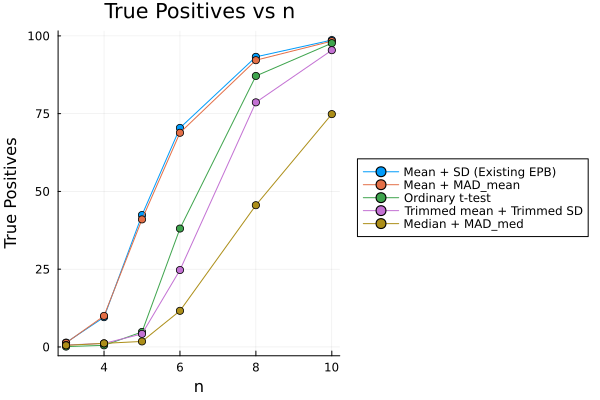

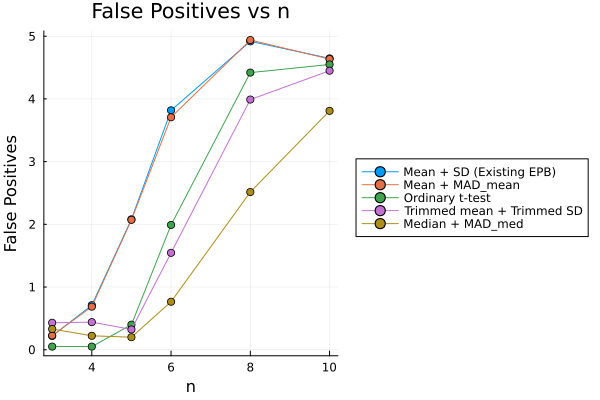

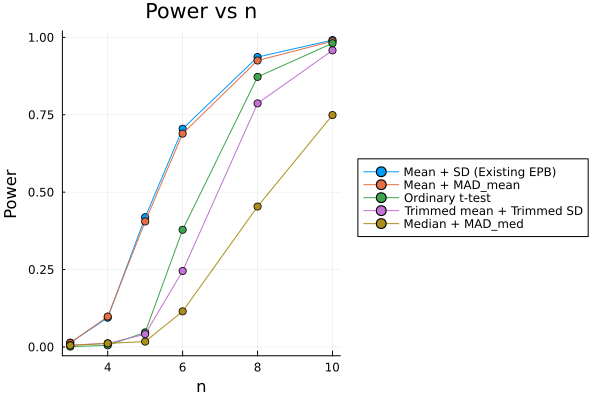

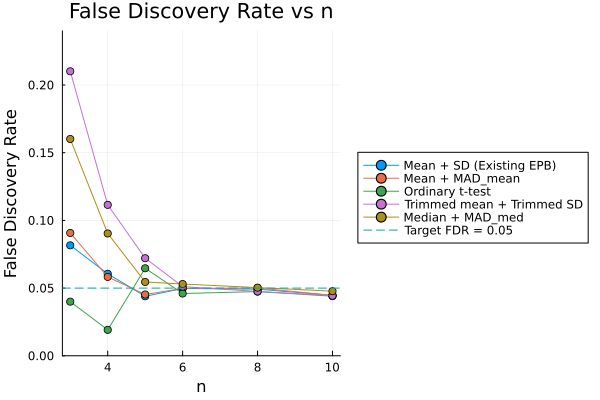

In [28]:
methods = Dict(
    "Mean + SD (Existing EPB)"     => epb_summary,
    "Mean + MAD_mean"              => mad_summary,
    "Median + MAD_med"             => med_summary,
    "Trimmed mean + Trimmed SD"    => trim_summary,
    "Ordinary t-test"              => ttest_summary
)

function get_xy(summary::Dict, key::String)
    n = summary["n"]
    y = summary[key]
    p = sortperm(n)
    return n[p], y[p]
end

using Plots
gr()

metrics = [
    ("TP",    "True Positives"),
    ("FP",    "False Positives"),
    ("Power", "Power"),
    ("FDR",   "False Discovery Rate"),
]

plots = Dict{String, Any}()

for (key, title_str) in metrics
    if key == "FDR"
        p = plot(
            xlabel = "n",
            ylabel = title_str,
            title = "$title_str vs n",
            legend = :outerright,
            ylims = (0, 0.24)
        )
    else
        p = plot(
            xlabel = "n",
            ylabel = title_str,
            title = "$title_str vs n",
            legend = :outerright
        )
    end

    for (name, summ) in methods
        x, y = get_xy(summ, key)
        plot!(p, x, y; marker = :circle, label = name)
    end

    if key == "FDR"
        hline!(p, [0.05], linestyle = :dash, label = "Target FDR = 0.05")
    end

    plots[key] = p
    display(p)
end